In [77]:
#testing the ODEsolving etc.

In [78]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [79]:
all_df = pd.read_csv('GSE124821_data.csv')

In [80]:
all_df[all_df['Condition']=='UV_day3']

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
32,SRX5100863,0.028508,0.006210,0.000195,0.004388,no_treatment,UV_day3,day3,GSM3554724,KPB25L
33,SRX5100861,0.044231,0.008691,0.001651,0.005400,no_treatment,UV_day3,day3,GSM3554725,KPB25L
34,SRX5100822,0.035853,0.011363,0.007057,0.005798,no_treatment,UV_day3,day3,GSM3554726,KPB25L
35,SRX5100823,0.029545,0.007832,0.000202,0.003111,antiPD1; antiCTLA4;,UV_day3,day3,GSM3554727,KPB25L
36,SRX5100820,0.025715,0.006015,0.002199,0.002836,no_treatment,UV_day3,day3,GSM3554728,KPB25L
43,SRX5100711,0.022124,0.005135,0.000000,0.002692,antiPD1; antiCTLA4;,UV_day3,day3,GSM3554735,KPB25L
44,SRX5100714,0.030504,0.006800,0.000199,0.003770,antiPD1; antiCTLA4;,UV_day3,day3,GSM3554736,KPB25L
166,SRX5100844,0.029855,0.013467,0.000000,0.005352,no_treatment,UV_day3,day3,GSM3554911,T11
167,SRX5100845,0.029797,0.012857,0.000000,0.004527,no_treatment,UV_day3,day3,GSM3554912,T11
168,SRX5100842,0.030162,0.012683,0.000000,0.005209,no_treatment,UV_day3,day3,GSM3554913,T11



Number of replicates 5
Dendritic_quanTIseq    0.030802
NK_quanTIseq           0.007164
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.003942
dtype: float64
<class 'pandas.Series'>

Number of replicates 4
Dendritic_quanTIseq    0.030666
NK_quanTIseq           0.010230
T.CD8_quanTIseq        0.000171
Tregs_quanTIseq        0.003666
dtype: float64
<class 'pandas.Series'>

Number of replicates 6
Dendritic_quanTIseq    0.024924
NK_quanTIseq           0.006209
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.002772
dtype: float64
<class 'pandas.Series'>


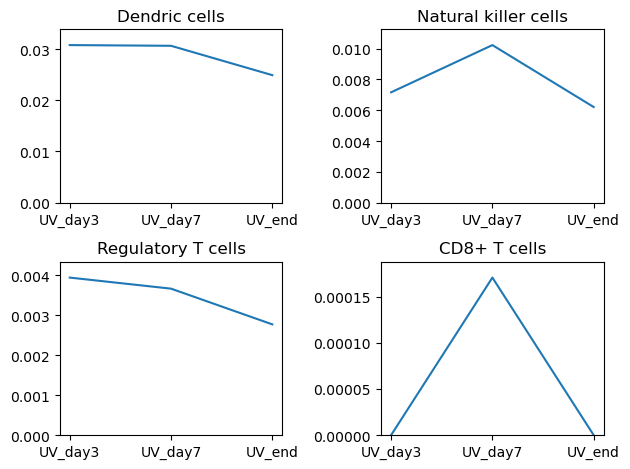

In [81]:
KPB25L_df = all_df[all_df['Cell_Line']=="KPB25L"]
no_treatment_KPB25L_df = KPB25L_df[KPB25L_df['Mouse_treatment']=="no_treatment"]
quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
Ds = []
NKs = []
T8s = []
Tregs = []

for day in ["day3","day7","end"]:
    day_df = no_treatment_KPB25L_df[no_treatment_KPB25L_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])

time_points = ["UV_day3","UV_day7","UV_end"]

fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,Ds)
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max(Ds)*1.1)
NKplot = ax[0,1]
NKplot.plot(time_points,NKs)
NKplot.set_title('Natural killer cells')
NKplot.set_ylim(0.0,max(NKs)*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,Tregs)
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max(Tregs)*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,T8s)
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max(T8s)*1.1)

plt.tight_layout()
plt.show()


Number of replicates 6
Dendritic_quanTIseq    0.002621
NK_quanTIseq           0.000863
T.CD8_quanTIseq        0.000039
Tregs_quanTIseq        0.000341
dtype: float64
<class 'pandas.Series'>
0.0038637831629999998

Number of replicates 10
Dendritic_quanTIseq    0.003434
NK_quanTIseq           0.001140
T.CD8_quanTIseq        0.000922
Tregs_quanTIseq        0.000652
dtype: float64
<class 'pandas.Series'>
0.006148045144

Number of replicates 9
Dendritic_quanTIseq    0.002638
NK_quanTIseq           0.001086
T.CD8_quanTIseq        0.000035
Tregs_quanTIseq        0.000401
dtype: float64
<class 'pandas.Series'>
0.004160221992666666

Number of replicates 19
Dendritic_quanTIseq    0.002335
NK_quanTIseq           0.000806
T.CD8_quanTIseq        0.000028
Tregs_quanTIseq        0.000360
dtype: float64
<class 'pandas.Series'>
0.0035284336252631573

Number of replicates 8
Dendritic_quanTIseq    0.003118
NK_quanTIseq           0.001121
T.CD8_quanTIseq        0.000053
Tregs_quanTIseq        0.000452
dt

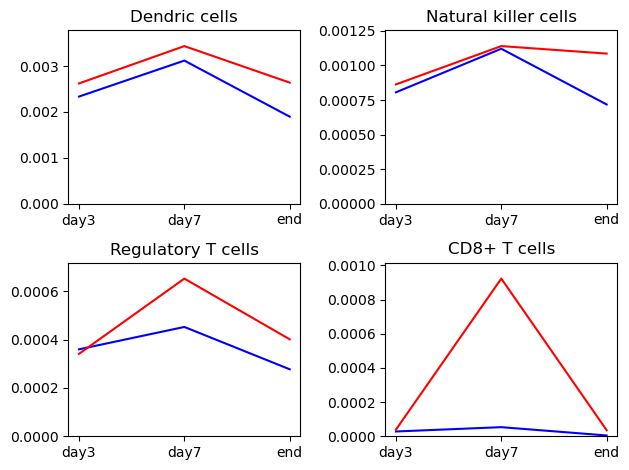

In [82]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')

no_treatment_df = all_df[all_df['Mouse_treatment']!="no_treatment"]

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

UV_Ds = []
UV_NKs = []
UV_T8s = []
UV_Tregs = []
UV_time_points = ["UV_day3","UV_day7","UV_end"]

for day in UV_time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    UV_Ds.append(averages["Dendritic_quanTIseq"])
    UV_NKs.append(averages["NK_quanTIseq"])
    UV_T8s.append(averages["T.CD8_quanTIseq"])
    UV_Tregs.append(averages["Tregs_quanTIseq"])
    UV_total = sum(averages)
    print(UV_total)
time_points = ["day3","day7","end"]

Ds = []
NKs = []
T8s = []
Tregs = []
scatter_Ds = []
scatter_NKs = []
scatter_Tregs = []
scatter_T8s = []
scatter_times = []

for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])
    total = sum(averages)
    print(total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_Ds.append(i)
                scatter_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_T8s.append(i)

print(scatter_Ds)
fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,Ds,'b')
Dplot.plot(time_points,UV_Ds,'r')
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*Ds,*UV_Ds])*1.1)
NKplot = ax[0,1]
NKplot.plot(time_points,NKs,'b')
NKplot.plot(time_points,UV_NKs,'r')
NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*NKs,*UV_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,Tregs,'b')
Tregplot.plot(time_points,UV_Tregs,'r')
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*Tregs,*UV_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,T8s,'b')
T8plot.plot(time_points,UV_T8s,'r')
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*T8s,*UV_T8s])*1.1)

plt.tight_layout()
plt.show()

In [98]:
import math

In [99]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.0,#0.17,
          'lambda_DC_comb':8e-5,
          # 'D_0':2e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4,
          'C_init':0.8,
          'D_init':0.0,
          'N_init':0.0,
          'Tr_init':0.0,
          'T8_init':0.0}
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
# D_0            = params['D_0']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
# Tr_0       = params['Tr_0']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
# T8_0       = params['T8_0']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = params['C_init']
D_init     = params['D_init']
N_init     = params['N_init']
Tr_init    = params['Tr_init']
T8_init    = params['T8_init']
# eta_N = 300
# eta_8 = 328.2
# lambda_C = 1*lambda_C
# d_Tr = 1*d_Tr
# sigma_N = 2*sigma_N
# lambda_Tr = 2*lambda_Tr
# lamba_T8 = 2*lambda_T8

objective_function_day3 = {'Ds':Ds[0],
                          'NKs':NKs[0],
                          'Tregs':Tregs[0],
                          'T8s':T8s[0]}
objective_function_day7 = {'Ds':Ds[1],
                          'NKs':NKs[1],
                          'Tregs':Tregs[1],
                          'T8s':T8s[1]}

print(Ds)

def mean_square_error(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5
        
        error+=(y[0,0]-objective_function_day3['C'])**2
        error+=(y[0,1]-objective_function_day7['C'])**2
    else:
        N = 2*4
    error+=(y[1,0]-objective_function_day3['Ds'])**2
    error+=(y[1,1]-objective_function_day7['Ds'])**2
    error+=(y[2,0]-objective_function_day3['NKs'])**2
    error+=(y[2,1]-objective_function_day7['NKs'])**2
    error+=(y[3,0]-objective_function_day3['Tregs'])**2
    error+=(y[3,1]-objective_function_day7['Tregs'])**2
    error+=(y[4,0]-objective_function_day3['T8s'])**2
    error+=(y[4,1]-objective_function_day7['T8s'])**2
    return math.sqrt(error/N)

def mean_square_error_rel(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

[np.float64(0.002334869778947368), np.float64(0.0031183833000000003), np.float64(0.0018968715374999999)]


In [109]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Treg': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.25e-3,1.5e-3,2.0e-3],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.5,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Treg': [1.e-7,5e-7,1.e-6,5e-6,7.5e-6,1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.175,0.2,0.5]}


In [ ]:
import itertools

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )
changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
for combo in itertools.product(*values):
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-8,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            best_params = params.copy()
            print(distance)
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

2.059194961728401
1.3790937127939784
1.1758452853099055
1.082865211596847
0.8088458341900785
0.8014244284225251
0.8010857994432604
0.800951840381677
0.8008745179271224
0.8007955843408701
0.8007715576577664
0.800637617182909
0.7968219236838046
0.789281391582314
0.7889388805869779
0.7888047609109597
0.7851350411149703
0.7847909979341584
0.7846565193953192
0.7795542333406642
0.7718426449455172
0.7714933371030197
0.7713573155168919
0.7684540579561838
0.7606248754465952
0.7602711640489238
0.7601342300084957
0.7403750029739818
0.7321064728546636
0.73175232280484
0.7316348038960756
0.5199881628678512
0.5005094998435309
0.5004318492378946
0.4994095229062027
0.49931384059184647
0.49869228061454857
0.4985788883774382
0.49846309759471663
0.49823126056351574
0.48232618483584555
0.48225462601929237
0.48118902067905894
0.48108407523978414
0.48044432004200316
0.47591007879893077
0.4758411307247493
0.4747592825891124
0.47465082215450727
0.4740044569938346
0.45455082615912157
0.4544905892475341
0.45335

/home/participant/miniforge3/envs/mibproject/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


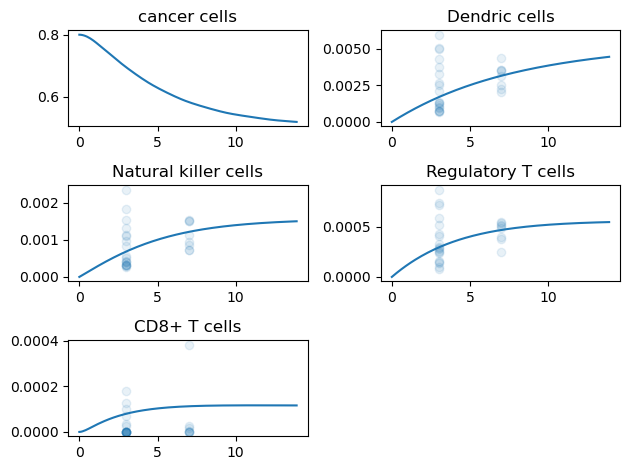

In [102]:
tspan = (0.0,14.0,)
C_init     = best_params['C_init']
D_init     = best_params['D_init']
N_init     = best_params['N_init']
Tr_init    = best_params['Tr_init']
T8_init    = best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))

t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1)

NK_cells = ax[1,0]
NK_cells.plot(t,y[2])

NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1)
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1)
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1)
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [61]:
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
# C0 = [0.8,0.0,0.0,0.00,0.0]

tspan = (0.0,50.0,)
import time

In [52]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

In [53]:
from matplotlib import pyplot as plt

NameError: name 'scatter_times' is not defined

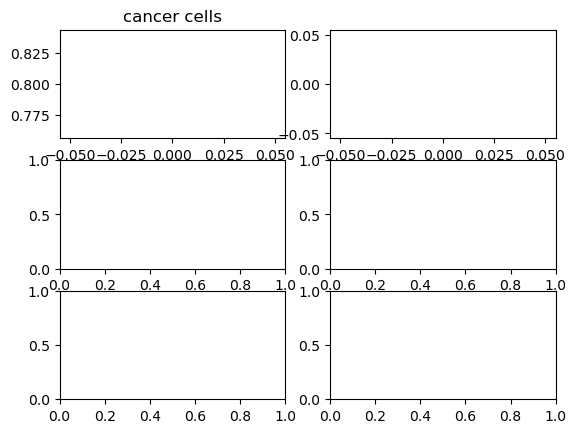

In [108]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],'b')
D_cells.scatter(scatter_times,scatter_Ds,'r')
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)

In [ ]:
param_grid = {
    'eta_8':[328.25]
    'eta_N':[300]
    'D0':[],
    'NK0':[],
    'Treg0':[],
    'T80':[0.0]
}

In [8]:
# parameters we are varying
y_data = np.array(
for param in param_grid:
    sigma_N,lambda_Tr,Tr_0,lambda_T8,T8_0,K_D,K_Tr=parm0 
    def cancer_ode_parametrised(t,y):
        return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
                   D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
                   beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
                  T8_0,K_D,K_Tr)
    tspan = (0.0,200.0,)
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

(5, 10)


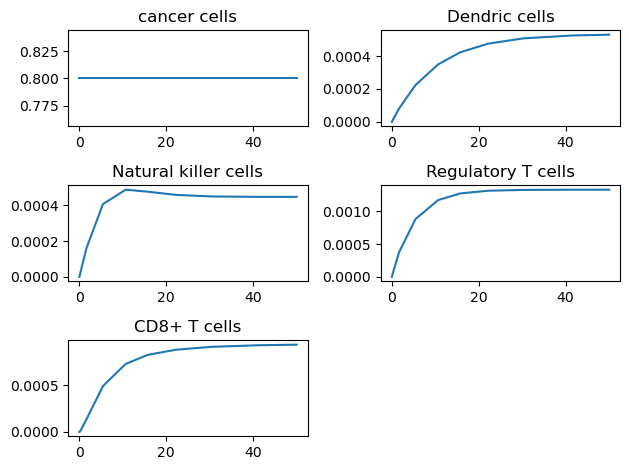

In [106]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

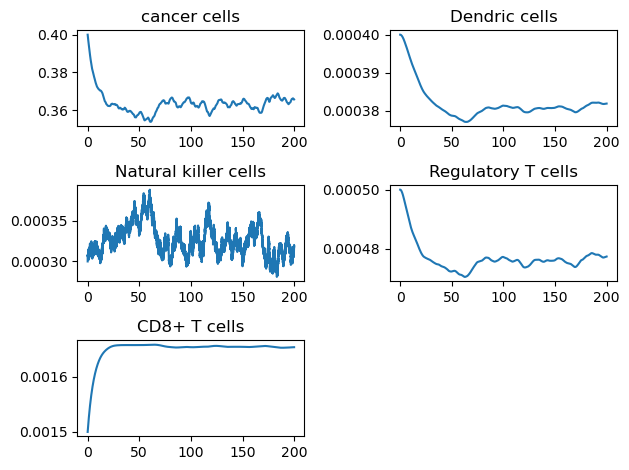

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
